Import all the necessary modules

In [169]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

Reading the CSV File


In [170]:
df1 = pd.read_csv("/content/Bengaluru_House_Data.csv")
df1.location = df1.location.str.lower()
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,electronic city phase ii,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,chikka tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [171]:
df1.shape

(13320, 9)

In [172]:
df1['area_type'].value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


Dropping columns that overcomplicates/are not relevant

In [173]:
df2 = df1.drop(['area_type', 'society', 'balcony', 'availability'], axis='columns')
df2.head()

,location,size,total_sqft,bath,price
0,electronic city phase ii,2 BHK,1056,2.0,39.07
1,chikka tirupathi,4 Bedroom,2600,5.0,120.00
2,uttarahalli,3 BHK,1440,2.0,62.00
3,lingadheeranahalli,3 BHK,1521,3.0,95.00
4,kothanur,2 BHK,1200,2.0,51.00


In [174]:
df2.isnull().sum()

,0
location,1
size,16
total_sqft,0
bath,73
price,0


In [175]:
df3 = df2.dropna()
df3.shape

(13246, 5)

In [176]:
df3.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In the size column, we can see that some are in the format BHK and some are in Bedroom, so let's see what's going on there

In [177]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [178]:
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

/tmp/ipython-input-2222900254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))


In [179]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,electronic city phase ii,2 BHK,1056,2.0,39.07,2
1,chikka tirupathi,4 Bedroom,2600,5.0,120.00,4
2,uttarahalli,3 BHK,1440,2.0,62.00,3
3,lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,kothanur,2 BHK,1200,2.0,51.00,2


In [180]:
df3['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [181]:
df3[df3['bhk']>20]

,location,size,total_sqft,bath,price,bhk
1718,2electronic city phase ii,27 BHK,8000,27.0,230.0,27
4684,munnekollal,43 Bedroom,2400,40.0,660.0,43


Let's investigate the total_sqft columns

In [182]:
df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

We need a single number and some of these (like 1133 - 1384) are ranges, so let's take the average of these numbers

In [183]:
def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [184]:
df3[~df3['total_sqft'].apply(is_float)]

,location,size,total_sqft,bath,price,bhk
30,yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th phase jp nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,kr puram,2 BHK,1015 - 1540,2.0,56.800,2
...,...,...,...,...,...,...
12975,whitefield,2 BHK,850 - 1060,2.0,38.190,2
12990,talaghattapura,3 BHK,1804 - 2273,3.0,122.000,3
13059,harlur,2 BHK,1200 - 1470,2.0,72.760,2
13265,hoodi,2 BHK,1133 - 1384,2.0,59.135,2


In [185]:
def convert_to_sqft(x):
  tokens = x.split('-')
  if len(tokens) == 2:
    return (float(tokens[0]) + float(tokens[1]))/2
  try:
    return float(x)
  except:
    return None


In [186]:
convert_to_sqft('21-66')

43.5

In [187]:
convert_to_sqft('2166')

2166.0

In [188]:
convert_to_sqft('34sqft')

In [189]:
df4 = df3.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_to_sqft)
df4.head()

,location,size,total_sqft,bath,price,bhk
0,electronic city phase ii,2 BHK,1056.0,2.0,39.07,2
1,chikka tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,kothanur,2 BHK,1200.0,2.0,51.00,2


In [190]:
df4.loc[30]

,30
location,yelahanka
size,4 BHK
total_sqft,2475.0
bath,4.0
price,186.0
bhk,4


Let's create a price per sqft columns

In [191]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,electronic city phase ii,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,chikka tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


Now, let's check how many locations we have in total

In [192]:
df5.location.nunique()

1294

In [193]:
df5.location.unique()

array(['electronic city phase ii', 'chikka tirupathi', 'uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'havanur extension', 'abshot layout'], dtype=object)

Here, we cannot do one hot encoding because there are too many locations. SO, as an alternative, let's try to get an "other" column for locations

In [194]:
df5.location = df5.location.apply(lambda x: x.strip())
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

,location
location,
whitefield,535
sarjapur road,392
electronic city,304
kanakpura road,266
thanisandra,236
...,...
viviani road,1
1st stage domlur,1
1st stage radha krishna layout,1


Let's make it so that any location with under 10 data points is considered "Other" location

In [195]:
len(location_stats[location_stats<=10])

1041

In [196]:
location_stats_less_than_ten = location_stats[location_stats<=10]
location_stats_less_than_ten

,location
location,
kalkere,10
1st block koramangala,10
sadashiva nagar,10
ganga nagar,10
sector 1 hsr layout,10
...,...
viviani road,1
1st stage domlur,1
1st stage radha krishna layout,1


In [197]:
df5.location.nunique()

1282

In [198]:
df5.location = df5.location.apply(lambda x: 'Other' if x in location_stats_less_than_ten else x )

In [199]:
df5.location.nunique()

242

In [200]:
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,electronic city phase ii,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,chikka tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,old airport road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,rajaji nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,Other,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


Usually, it's 300 sqft per bedroom, so let's check for outliers with that info

In [201]:
df5[df5.total_sqft/df5['bhk']<300]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,Other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,hsr layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,Other,3 Bedroom,500.0,3.0,100.0,3,20000.000000
...,...,...,...,...,...,...,...
13277,Other,7 Bedroom,1400.0,7.0,218.0,7,15571.428571
13279,Other,6 Bedroom,1200.0,5.0,130.0,6,10833.333333
13281,margondanahalli,5 Bedroom,1375.0,5.0,125.0,5,9090.909091
13303,vidyaranyapura,5 Bedroom,774.0,5.0,70.0,5,9043.927649


In [202]:
len(df5[df5.total_sqft/df5['bhk']<300])

744

In [203]:
df5.shape

(13246, 7)

In [204]:
df6 = df5[~(df5.total_sqft/df5['bhk']<300)]
df6.shape

(12502, 7)

In [205]:
df6['price_per_sqft'].describe()

,price_per_sqft
count,12456.000000
mean,6308.502826
std,4168.127339
min,267.829813
25%,4210.526316
50%,5294.117647
75%,6916.666667
max,176470.588235


In [206]:
def remove_outliers(df):
  df_out = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    m = np.mean(subdf.price_per_sqft)
    st = np.std(subdf.price_per_sqft)
    reduced_df = subdf[(subdf.price_per_sqft > (m-st)) & (subdf.price_per_sqft <= (m+st))]
    df_out = pd.concat([df_out, reduced_df], ignore_index=True)
  return df_out

In [207]:
df7 = remove_outliers(df6)
df7.shape

(10241, 7)

Next, we have to check if the property prices for 3 bedroom apartments are more than the property price for 2 bedroom apartment in the same area with a similar sqft

In [208]:
def plot_scatter_chart(df, location):
  bhk2 = df[(df.location==location) & (df.bhk==2)]
  bhk3 = df[(df.location ==location) & (df.bhk == 3)]
  matplotlib.rcParams['figure.figsize'] = (15,10)
  plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 BHK', s = 50)
  plt.scatter(bhk3.total_sqft, bhk3.price, marker='+', color='green', label='3 BHK', s = 50)
  plt.xlabel("Total Square Feet area")
  plt.ylabel("Price per square feet")
  plt.title(location)
  plt.legend()
  plt.show()

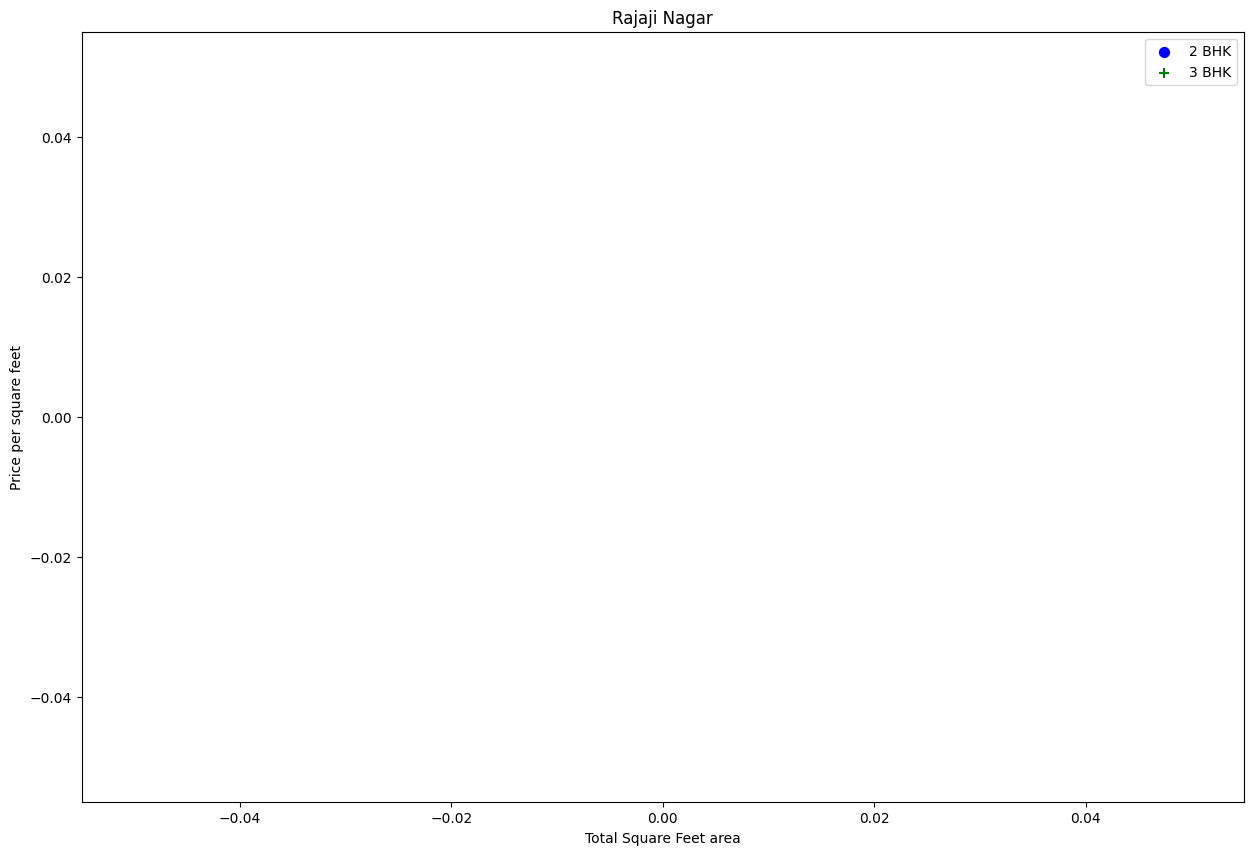

In [209]:
plot_scatter_chart(df7, "Rajaji Nagar")

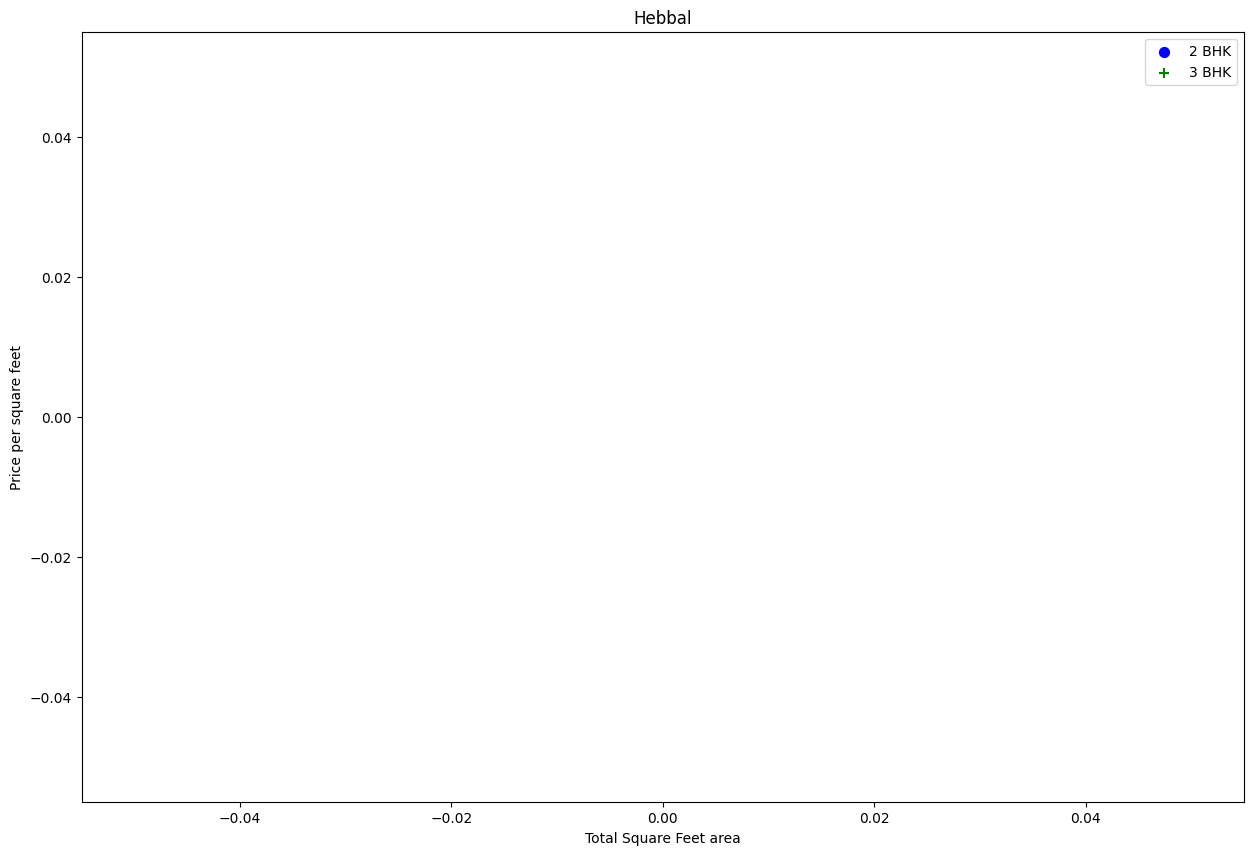

In [210]:
plot_scatter_chart(df7, "Hebbal")

As you can see, there are outliers, so it's time to remove them
I'll create statistics, creating a dictionary, where I will calculate mean, st deviation, and count. I'll then filter out 2 bedroom apartments who's price per sqft is less than mean of 1 BHK apartment

In [211]:
def remove_bhk_outliers(df):
  exclude_indices = np.array([])
  for location, location_df in df.groupby('location'):
    bhk_stats = {}
    for bhk, bhk_df in location_df.groupby('bhk'):
      bhk_stats[bhk] = {
          'mean': np.mean(bhk_df.price_per_sqft),
          'std': np.std(bhk_df.price_per_sqft),
          'count': bhk_df.shape[0]
      }
    for bhk,bhk_df in location_df.groupby('bhk'):
      stats = bhk_stats.get(bhk-1)
      if stats and stats['count']>5:
        exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
  return df.drop(exclude_indices, axis='index')



In [212]:
df8 = remove_bhk_outliers(df7)
df8.shape

(7329, 7)

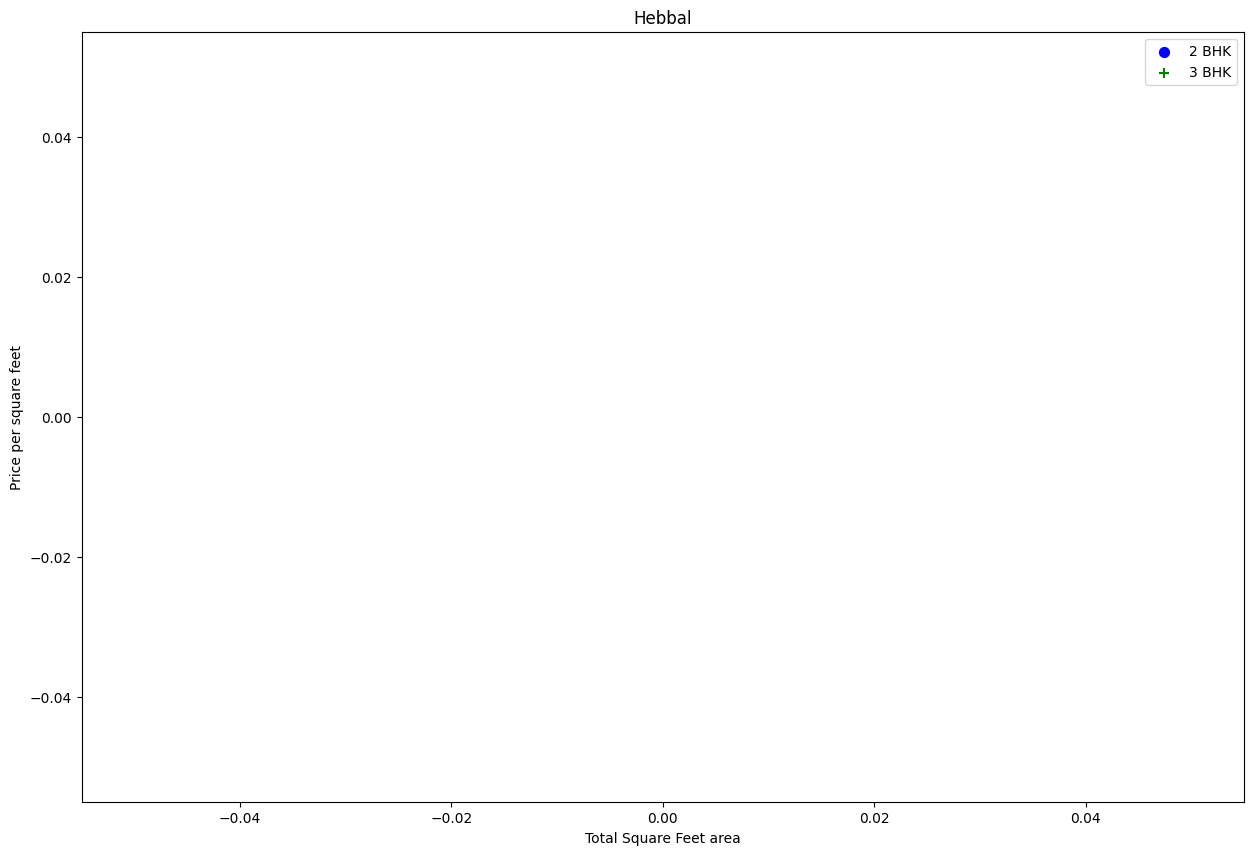

In [213]:
plot_scatter_chart(df8, "Hebbal")

All those green data points (outliers) we had are gone

Let's now plot a histogram to see how many apartments we have in per_sqft area

Text(0, 0.5, 'Count')

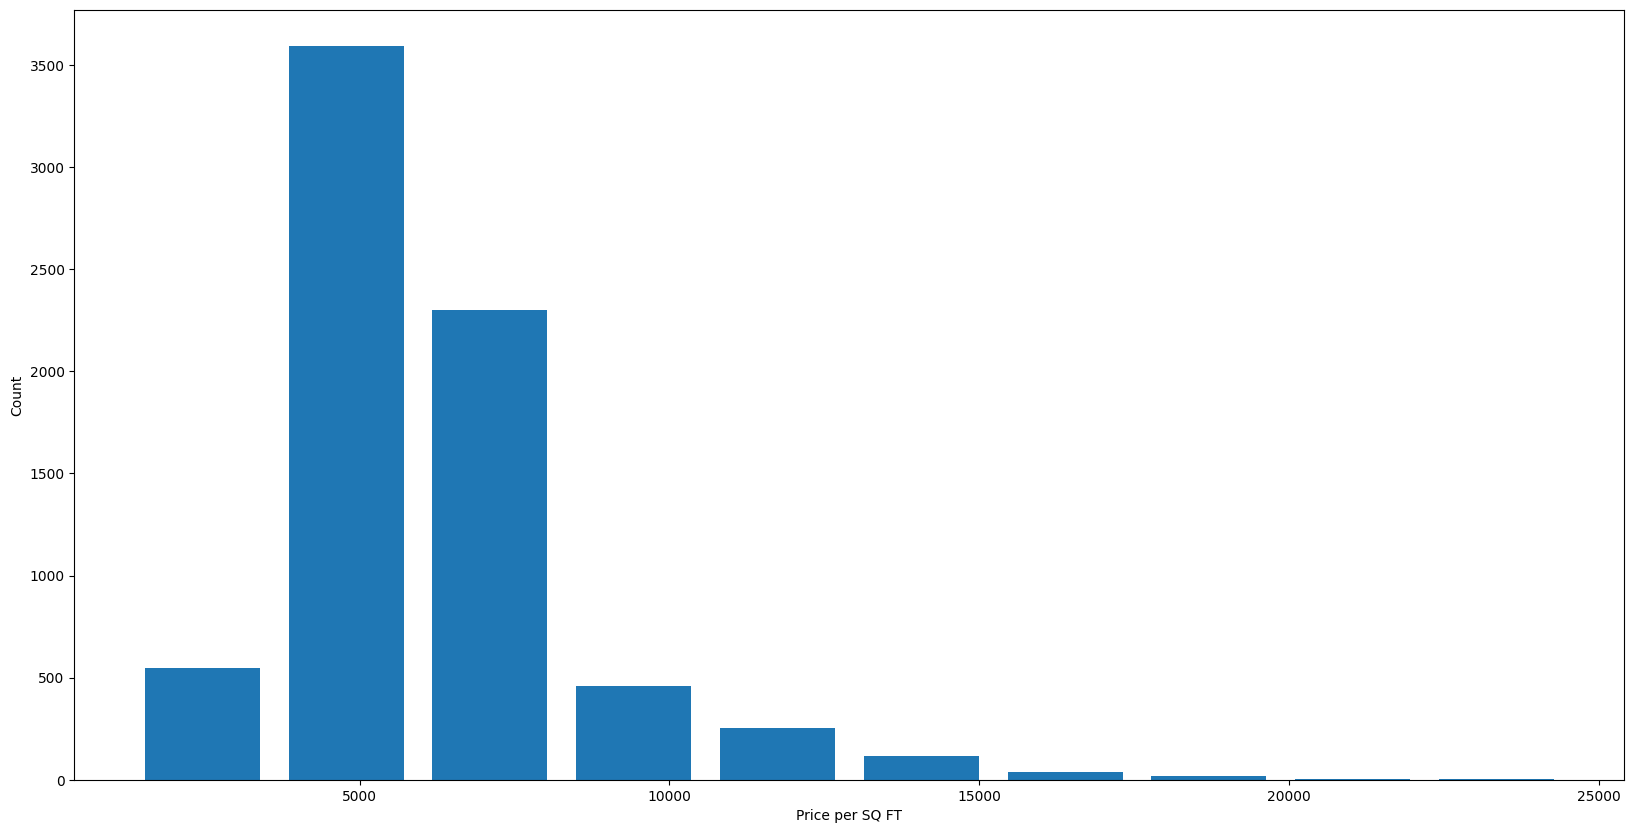

In [214]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df8.price_per_sqft,rwidth=0.8)
plt.xlabel("Price per SQ FT")
plt.ylabel("Count")

Let's now investigate the bath features

In [215]:
df8.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  9.,  6., 12., 16.,  7., 13.])

In [216]:
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
817,Other,10 BHK,12000.0,12.0,525.0,10,4375.000000
906,Other,16 BHK,10000.0,16.0,550.0,16,5500.000000
1639,Other,11 BHK,6000.0,12.0,150.0,11,2500.000000
1970,Other,13 BHK,5425.0,13.0,275.0,13,5069.124424
7562,neeladri nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000


Text(0, 0.5, 'Count')

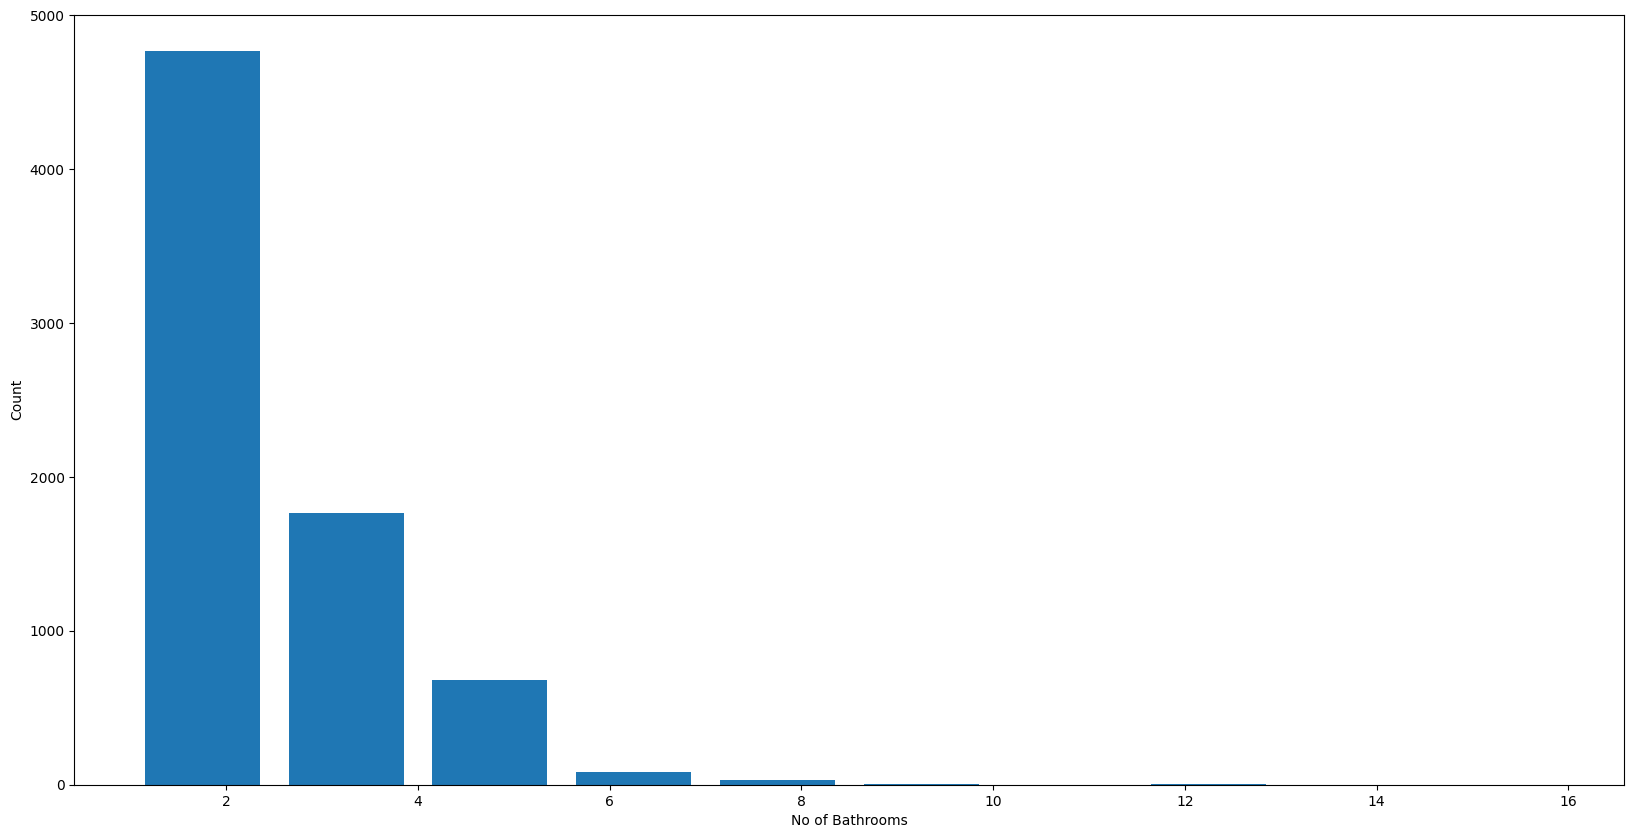

In [217]:
plt.hist(df8.bath,rwidth=0.8)
plt.xlabel("No of Bathrooms")
plt.ylabel("Count")

It's abnormal to have more bathrooms than bedrooms. So, every time we have 2 more bathrooms than bedrooms, we'll remove that data point

In [218]:
df8[df8.bath>df8.bhk+2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
742,Other,6 BHK,11338.0,9.0,1000.0,6,8819.897689
3900,chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
7523,nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
9012,thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330


In [219]:
df9 = df8[df8.bath<df8.bhk+2]
df9.shape

(7251, 7)

It's almost time to start machine learning, so let's drop size (because we already have bhk) and price_per_sqft (because we don't need it)

In [220]:
df10 = df9.drop(['size', 'price_per_sqft'], axis='columns')
df10.sample(10)

,location,total_sqft,bath,price,bhk
3799,chandapura,975.0,2.0,24.86,2
1616,Other,825.0,2.0,40.00,1
1458,Other,2400.0,2.0,135.00,2
127,7th phase jp nagar,1300.0,3.0,89.13,3
9134,ulsoor,2135.0,3.0,170.00,3
3287,begur road,1410.0,2.0,53.00,3
9867,whitefield,1277.0,2.0,77.00,2
4569,electronic city phase ii,1065.0,2.0,30.76,2
8280,sarjapur,1128.0,2.0,60.00,2
5794,indira nagar,2070.0,3.0,225.00,3


Since the location is a text column, let's use one hot encoding to numerize it

In [221]:
dummies = pd.get_dummies(df10.location)
dummies

,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,6th phase jp nagar,7th phase jp nagar,8th phase jp nagar,9th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10231,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10233,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10238,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [222]:
df11 = pd.concat([df10, dummies.drop('Other', axis='columns')], axis='columns')
df11.head()

,location,total_sqft,bath,price,bhk,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,1st block jayanagar,2850.0,4.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st block jayanagar,1630.0,3.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st block jayanagar,1875.0,2.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st block jayanagar,1200.0,2.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st block jayanagar,1235.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [223]:
df12 = df11.drop('location', axis='columns')
df12.head()

,total_sqft,bath,price,bhk,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,2850.0,4.0,428.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,130.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,148.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [224]:
df12.shape

(7251, 245)

In [225]:
X = df12.drop('price', axis='columns')
y = df12.price

In [226]:
X.head()

,total_sqft,bath,bhk,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,6th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [227]:
y.head()

,price
0,428.0
1,194.0
2,235.0
3,130.0
4,148.0


Let's now split our data into training and test and do linear regression to see what our score is

In [228]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=10)

In [229]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train, y_train)

LinearRegression()

In [230]:
lr_clf.score(X_test, y_test)

0.8514071948152184

It's good but we can get it better. Let's use K fold cross validation to fevaluate

In [231]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.83467103, 0.84965498, 0.83411538, 0.86241426, 0.87583675])

Now let's use gridsearchcv to find the best model out there

In [232]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

def find_the_best_model(X,y):
  algorithms = {
      'linear_regression': {
            'model' : LinearRegression(),
            'params':{
                'fit_intercept':[True,False],
            }
      },
      'lasso':{
          'model' : Lasso(),
          'params' : {
              'alpha': [1,2],
              'selection': ['random', 'cyclic']

          }
      },
      'decision_tree': {
          'model': DecisionTreeRegressor(),
          'params': {
              'criterion': ['squared_error', 'friedman_mse'],
              'splitter': ['best', 'random']
          }
      },

      'random_forest': {
          'model': RandomForestRegressor(),
          'params': {
              'n_estimators': [10, 50, 100],
              'max_features': ['sqrt']
          }
      }
  }
  scores = []
  cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
  for algo_name, config in algorithms.items():
    gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
    gs.fit(X,y)
    scores.append({
        'model': algo_name,
        'best_score': gs.best_score_,
        'best_params': gs.best_params_
    })

  return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

In [233]:
find_the_best_model(X,y)

,model,best_score,best_params
0,linear_regression,0.851692,{'fit_intercept': False}
1,lasso,0.703089,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.748312,"{'criterion': 'friedman_mse', 'splitter': 'ran..."
3,random_forest,0.846876,"{'max_features': 'sqrt', 'n_estimators': 100}"


Alright, so it turns out linear regression was the best model, so we can proceed with that

In [234]:
def predict_prize(location, sqft, bath, bhk):
  location = location.lower()
  x = np.zeros(len(X.columns))
  x[0] = sqft
  x[1] = bath
  x[2] = bhk

  try:
    loc_col_index = X.columns.get_loc(location)

    if loc_col_index >= 3:
      x[loc_col_index] = 1
  except KeyError:
    pass

  return lr_clf.predict([x])[0]

Now it's time to predict prizes

In [235]:
print(predict_prize(('1st Phase JP Nagar'), 1000, 2, 2))

84.61906655326976


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Now, we can export our model

In [236]:
X.head()

,total_sqft,bath,bhk,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,6th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [237]:
import pickle
with open('home_prices_model.pickle','wb') as f:
  pickle.dump(lr_clf,f)

We also need our column information, so we'll export that too

In [238]:
import json
columns = {
    'data_columns': [col.lower() if isinstance(col, str) else col for col in X.columns]
}
with open("columns.json", 'w') as f:
  f.write(json.dumps(columns))

In [239]:
X.head()

,total_sqft,bath,bhk,1st block jayanagar,1st phase jp nagar,2nd phase judicial layout,2nd stage nagarbhavi,5th block hbr layout,5th phase jp nagar,6th phase jp nagar,...,vijayanagar,vishveshwarya layout,vishwapriya layout,vittasandra,whitefield,yelachenahalli,yelahanka,yelahanka new town,yelenahalli,yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [240]:
predict_prize('1st Phase JP Nagar',1000, 3, 3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(86.84820028884016)

In [241]:
predict_prize('1st Phase JP Nagar', 1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(84.61906655326976)

In [242]:
predict_prize('Kalhalli', 1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(80.5894509688884)

In [243]:
predict_prize('Ejipura', 1000, 4, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(85.14467050298363)